# Random Forest with Gini Criterion — Balanced Data
## Wisconsin Breast Cancer Dataset
### Pipeline: Load (balanced) → 80/20 Split → Scale → Train RF(gini) → Evaluate

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load balanced dataset
df = pd.read_csv('../../balanced_data.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Dataset shape: (714, 31)
Columns: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'diagnosis']


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1


In [3]:
# Check class distribution in balanced data
print(f"Class distribution:\n{df['diagnosis'].value_counts()}")
print(f"\nMalignant (1): {df['diagnosis'].sum()} cases")
print(f"Benign    (0): {len(df) - df['diagnosis'].sum()} cases")

Class distribution:
diagnosis
1    357
0    357
Name: count, dtype: int64

Malignant (1): 357 cases
Benign    (0): 357 cases


In [4]:
# Separate features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# 80/20 train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Train size: 571 samples
Test size:  143 samples

Train class distribution:
diagnosis
1    286
0    285
Name: count, dtype: int64

Test class distribution:
diagnosis
0    72
1    71
Name: count, dtype: int64


In [5]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized successfully.")

Features standardized successfully.


In [6]:
# Train Random Forest with Gini criterion on BALANCED data
rf_gini = RandomForestClassifier(criterion='gini', random_state=42)
rf_gini.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf_gini.predict(X_test_scaled)
y_proba = rf_gini.predict_proba(X_test_scaled)[:, 1]

print("Model trained on BALANCED data.")

Model trained on BALANCED data.


In [7]:
# --- 6 Metrics ---

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Confusion Matrix → extract TN, FP, FN, TP for Specificity
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

roc_auc = roc_auc_score(y_test, y_proba)

# Display results
print("=" * 55)
print("Random Forest (Gini) — BALANCED Data Results")
print("=" * 55)
print(f"Accuracy:     {accuracy:.4f}")
print(f"Precision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"F1-score:     {f1:.4f}")
print(f"Specificity:  {specificity:.4f}")
print(f"ROC-AUC:      {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(f"              Predicted")
print(f"              Neg    Pos")
print(f"Actual Neg    {tn:3d}   {fp:2d}")
print(f"       Pos    {fn:2d}   {tp:3d}")

Random Forest (Gini) — BALANCED Data Results
Accuracy:     0.9790
Precision:    1.0000
Recall:       0.9577
F1-score:     0.9784
Specificity:  1.0000
ROC-AUC:      0.9982

Confusion Matrix:
              Predicted
              Neg    Pos
Actual Neg     72    0
       Pos     3    68


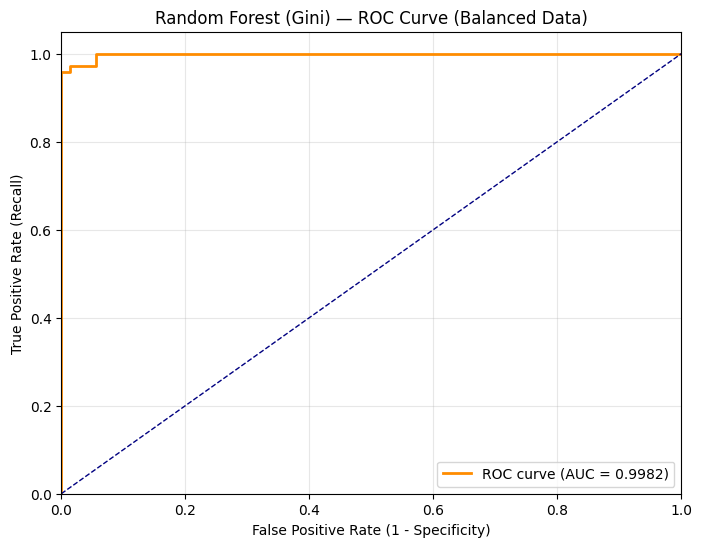

In [8]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Random Forest (Gini) — ROC Curve (Balanced Data)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()